<a href="https://colab.research.google.com/github/ahmed-tech426/anime-website/blob/main/code_x2pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("fitness_tracker_dataset.csv")
print(df.shape)
print(df.head())
print(df.isnull().sum())

(1000000, 12)
   user_id        date  steps  calories_burned  distance_km  active_minutes  \
0      468  2023-01-01   4530          2543.02        16.10             613   
1      879  2023-01-01  11613          1720.76         8.10             352   
2      152  2023-01-01  27335          1706.35         3.57             236   
3      311  2023-01-01  13459          2912.38         6.41            1329   
4      759  2023-01-01  15378          3344.51        17.88              52   

   sleep_hours  heart_rate_avg workout_type weather_conditions location  \
0          1.5             176      Walking              Clear     Park   
1          6.3             128      Cycling                Fog     Park   
2          6.7             134         Yoga               Snow     Park   
3         11.6             116     Swimming               Rain   Office   
4          7.4              84     Swimming               Rain   Office   

      mood  
0    Tired  
1    Happy  
2  Neutral  
3    Tir

In [2]:
df = df.drop(columns=['user_id', 'date'])
df['workout_type'] = df['workout_type'].fillna('Unknown')
print(df.shape)

(1000000, 10)


In [3]:
def get_fatigue(row):
    score = 0
    if row['sleep_hours'] < 5: score += 2
    elif row['sleep_hours'] < 7: score += 1
    if row['heart_rate_avg'] > 150: score += 2
    elif row['heart_rate_avg'] > 120: score += 1
    if row['active_minutes'] > 600: score += 2
    elif row['active_minutes'] > 300: score += 1
    if row['mood'] == 'Tired': score += 2
    elif row['mood'] == 'Stressed': score += 1
    if score >= 4: return 'High'
    elif score >= 2: return 'Medium'
    else: return 'Low'

df['fatigue_level'] = df.apply(get_fatigue, axis=1)
df = df.drop(columns=['mood'])

print(df['fatigue_level'].value_counts())

fatigue_level
High      584846
Medium    339219
Low        75935
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['workout_type', 'weather_conditions', 'location', 'fatigue_level']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   steps  calories_burned  distance_km  active_minutes  sleep_hours  \
0   4530          2543.02        16.10             613          1.5   
1  11613          1720.76         8.10             352          6.3   
2  27335          1706.35         3.57             236          6.7   
3  13459          2912.38         6.41            1329         11.6   
4  15378          3344.51        17.88              52          7.4   

   heart_rate_avg  workout_type  weather_conditions  location  fatigue_level  
0             176             5                   0         4              0  
1             128             0                   1         4              2  
2             134             6                   3         4              2  
3             116             3                   2         2              0  
4              84             3                   2         2              1  


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fatigue_level'])
y = df['fatigue_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(800000, 9) (200000, 9)


In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=7)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

feature_names = X.columns
selected = feature_names[selector.get_support()]
print("Selected features:", list(selected))

Selected features: ['calories_burned', 'distance_km', 'active_minutes', 'sleep_hours', 'heart_rate_avg', 'workout_type', 'location']


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

print("done")

done


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

scaler2 = StandardScaler()
X_train_full = scaler2.fit_transform(X_train)
X_test_full = scaler2.transform(X_test)

rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train_full, y_train)

print("Accuracy before selection:", accuracy_score(y_test, rf_full.predict(X_test_full)))

Accuracy before selection: 0.778375


In [9]:
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)

print("Accuracy after selection:", accuracy_score(y_test, rf_selected.predict(X_test_selected)))

Accuracy after selection: 0.778555


In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_selected, y_train)
X_test_lda = lda.transform(X_test_selected)

print(X_train_lda.shape)

(800000, 2)


In [11]:
rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_lda.fit(X_train_lda, y_train)

print("Accuracy after LDA:", accuracy_score(y_test, rf_lda.predict(X_test_lda)))

Accuracy after LDA: 0.730955


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_selected, y_train)
print("LR after selection:", accuracy_score(y_test, lr.predict(X_test_selected)))

lr_lda = LogisticRegression(max_iter=1000, random_state=42)
lr_lda.fit(X_train_lda, y_train)
print("LR after LDA:", accuracy_score(y_test, lr_lda.predict(X_test_lda)))

LR after selection: 0.745285
LR after LDA: 0.745155


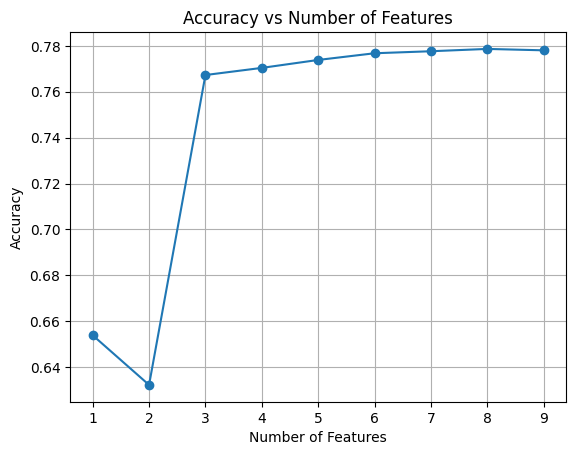

In [13]:
import matplotlib.pyplot as plt

X_sample = X_train[:100000]
y_sample = y_train[:100000]

k_values = range(1, 10)
accuracies = []

for k in k_values:
    sel = SelectKBest(f_classif, k=k)
    X_tr = sel.fit_transform(X_sample, y_sample)
    X_te = sel.transform(X_test)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    rf_k = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf_k.fit(X_tr, y_sample)
    accuracies.append(accuracy_score(y_test, rf_k.predict(X_te)))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Features")
plt.grid(True)
plt.show()

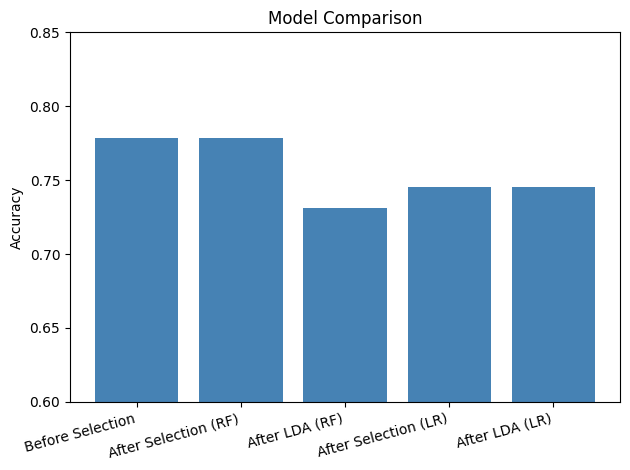

In [14]:
labels = ['Before Selection', 'After Selection (RF)', 'After LDA (RF)', 'After Selection (LR)', 'After LDA (LR)']
values = [0.778375, 0.778555, 0.730955, 0.745285, 0.745155]

plt.bar(labels, values, color='steelblue')
plt.ylim(0.6, 0.85)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report

print("RF after Selection:")
print(classification_report(y_test, rf_selected.predict(X_test_selected)))

print("LR after Selection:")
print(classification_report(y_test, lr.predict(X_test_selected)))

RF after Selection:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85    117076
           1       0.63      0.72      0.67     15294
           2       0.65      0.74      0.69     67630

    accuracy                           0.78    200000
   macro avg       0.73      0.76      0.74    200000
weighted avg       0.79      0.78      0.78    200000

LR after Selection:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84    117076
           1       0.65      0.47      0.55     15294
           2       0.63      0.62      0.62     67630

    accuracy                           0.75    200000
   macro avg       0.70      0.65      0.67    200000
weighted avg       0.74      0.75      0.74    200000



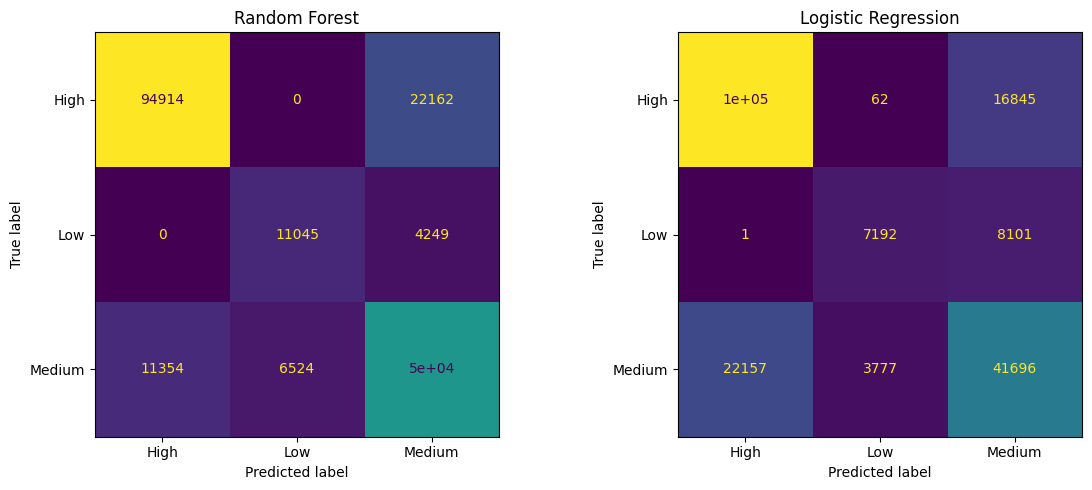

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(y_test, rf_selected.predict(X_test_selected))
ConfusionMatrixDisplay(cm_rf, display_labels=['High', 'Low', 'Medium']).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

cm_lr = confusion_matrix(y_test, lr.predict(X_test_selected))
ConfusionMatrixDisplay(cm_lr, display_labels=['High', 'Low', 'Medium']).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()